In [1]:
import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import  Ball3StickSharedDiffusivity

In [2]:

sim_type = Ball3StickSharedDiffusivity
ball_stick = sim_type.from_theta(np.random.randn(sim_type.theta_dim))

In [3]:
from dmri.simulators.acquisition_scheme import acquisition_scheme, random_hcp_acquisition

sim_type.fraction_prior = jnp.array([3., 1.0, 0.2, 0.1])
@jax.jit
def simulator(rng):
    rng0, rng1, rng2, rng3, rng4, rng5 = jax.random.split(rng, 6)
    acq = random_hcp_acquisition(rng)


    theta = jax.random.normal(rng1, shape=(sim_type.theta_dim,))
    rng_p, rng_m = jax.random.split(rng2)
    p_mask = jax.random.beta(rng_p, a=1, b=1, shape=(1,))
    #model_mask = jax.random.bernoulli(rng_m, p=p_mask, shape=(len(sim_type.model_types)))
    model_mask = jnp.ones(len(sim_type.model_types), dtype=jnp.bool)
    # This needs to have only one entry
    model_noise_idx = jax.random.randint(rng4, minval=0, maxval=len(sim_type.noise_types), shape=(1,))
    model_noise_mask = jnp.zeros(len(sim_type.noise_types), dtype=jnp.bool)
    model_noise_mask = model_noise_mask.at[model_noise_idx].set(True)
    model_mask = jnp.concatenate([model_mask, model_noise_mask], axis=-1)
    ball_stick = sim_type.from_theta(theta, model_mask=model_mask)

    @jax.grad
    def posterior_score(theta, x):
        ball_stick = sim_type.from_theta(theta, model_mask=model_mask)
        return ball_stick.log_likelihood(acq, x) + jax.scipy.stats.norm.logpdf(theta, 0, 1).sum(-1)

    x_o = ball_stick.signal(acq, rng=rng5)
    score = posterior_score(theta, x_o)
    return p_mask, model_mask, theta, x_o, acq, score


In [4]:
from dmri.train.dataloader import StreamDataLoader
import time
dataloader = StreamDataLoader(simulator, batch_size=5096, num_producers=1)

In [5]:
datastream = iter(dataloader)


In [6]:
dataloader.queue_size()

3

In [8]:
times = []
for _ in range(100):
    start = time.time()
    data = next(datastream)
    print(data[0].block_until_ready().sum())
    time.sleep(0.01)
    end = time.time()
    times.append(end - start)


8
2527.5557
8
2545.4346
8
2583.9736
8
2566.7295
8
2550.5085
8
2580.5137
8
2552.1335
8
2540.258
8
2583.9736
8
2528.3765
8
2542.5312
8
2566.7295
8
2527.5557
8
2545.4346
8
2532.0046
8
2550.5085
8
2580.5137
8
2552.1335
8
2529.3662
8
2550.5293
8
2543.7444
8
2574.822
8
2540.2683
8
2505.6738
7
2577.9995
6
2544.978
5
2526.3965
4
2507.2866
4
2537.1553
4
2585.0542
4
2539.3857
4
2507.2866
4
2537.1553
4
2585.0542
4
2539.3857
4
2507.2866
4
2537.1553
4
2585.0542
4
2539.3857
4
2507.2866
4
2537.1553
4
2585.0542
4
2539.3857
4
2507.2866
4
2537.1553
4
2585.0542
4
2539.3857
4
2507.2866
4
2537.1553
4
2585.0542
4
2539.3857
4
2507.2866
4
2537.1553
4
2585.0542
4
2539.3857
4
2507.2866
4
2537.1553
5
2585.0542
4
2539.3857
4
2507.2866
4
2537.1553
4
2542.5017
4
2539.3857
4
2507.2866
4
2537.1553
4
2542.5017
4
2539.3857
4
2507.2866
4
2537.1553
4
2542.5017
4
2539.3857
4
2507.2866
4
2537.1553
4
2542.5017
4
2539.3857
4
2507.2866
4
2537.1553
4
2542.5017
4
2539.3857
4
2507.2866
4
2537.1553
4
2542.5017
4
2539.3857
4
2507.

(array([24., 14.,  3.,  1.,  0.,  0.,  0.,  2.,  7.,  3.,  4.,  2.,  3.,
         2.,  4.,  2.,  3.,  1.,  2.,  1.,  1.,  1.,  0.,  1.,  2.,  1.,
         0.,  0.,  0.,  3.,  0.,  0.,  2.,  0.,  1.,  0.,  0.,  2.,  0.,
         0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,
         0.,  0.,  1.,  0.,  1.,  0.,  0.,  1.,  0.,  0.,  0.,  1.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([0.00108099, 0.00108858, 0.00109617, 0.00110376, 0.00111135,
        0.00111893, 0.00112652, 0.00113411, 0.0011417 , 0.00114929,
        0.00115688, 0.00116447, 0.00117206, 0.00117965, 0.00118723,
        0.00119482, 0.00120241, 0.00121   , 0.00121759, 0.00122518,
        0.00123277, 0.00124036, 0.00124794, 0.00125553, 0.00126312,
        0.00127071, 0.0012783 , 0.00128589, 0.00129348, 0.00130107,
        0.00130866, 0.0013

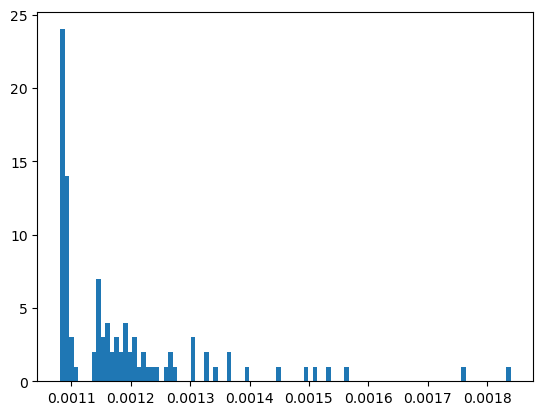

In [11]:
plt.hist(times, bins=100)